# Анализ рынка авокадо в США (2015–2018)

**Датасет:** [Avocado Prices](https://www.kaggle.com/datasets/neuromusic/avocado-prices) (Kaggle) — еженедельные данные по цене и объёму продаж авокадо в 54 регионах США, включая деление на `conventional` и `organic`.

**Вопрос исследования:**
1. Как менялась цена на авокадо в 2015–2018 годах и есть ли сезонность?
2. Насколько органический авокадо дороже обычного и растёт ли доля органики в продажах?
3. В каких регионах авокадо дороже/дешевле всего?
4. Как связаны цена и объём продаж?

Структура ноутбука: загрузка и проверка данных → описательная статистика → динамика цен → organic vs conventional → анализ по регионам → связь цены и объёма → аналитика в духе SQL-оконных функций на pandas → итоговые выводы.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('data/avocado.csv')
df = df.drop(columns=['Id'])
df['Date'] = pd.to_datetime(df['Date'])

print('Размер датасета:', df.shape)
df.info()


Размер датасета: (18249, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB


## 1. Первичный осмотр данных

In [46]:
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [47]:
# в датасете есть агрегированные "регионы" (TotalUS, West, Southeast и т.д.),
# которые дублируют суммы по городам. Отделяем их, чтобы не считать город + регион дважды.
AGGREGATE_REGIONS = ['TotalUS', 'West', 'SouthCentral', 'Northeast', 'Southeast',
                      'Midsouth', 'Plains', 'GreatLakes', 'WestTexNewMexico']

city_df = df[~df['region'].isin(AGGREGATE_REGIONS)].copy()
us_df = df[df['region'] == 'TotalUS'].copy()

print(f"Всего регионов: {df['region'].nunique()}")
print(f"Из них 'городских': {city_df['region'].nunique()}, агрегированных: {len(AGGREGATE_REGIONS)}")
print(f"Период данных: {df['Date'].min().date()} — {df['Date'].max().date()}")


Всего регионов: 54
Из них 'городских': 45, агрегированных: 9
Период данных: 2015-01-04 — 2018-03-25


## 2. Пропущенные значения

In [48]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Колонки с пропусками:")
print(missing if len(missing) else "Пропусков нет — данные полные.")


Колонки с пропусками:
Пропусков нет — данные полные.


**Вывод по пропускам:** пропусков в данных нет, все 18 249 строк пригодны для анализа без дополнительной чистки.

## 3. Описательные статистики

In [49]:
df.describe()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,2016-08-13 23:30:43.498273792,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
min,2015-01-04 00:00:00,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,2015-10-25 00:00:00,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,2016-08-14 00:00:00,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,2017-06-04 00:00:00,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,2018-03-25 00:00:00,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000
std,NaN,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938


## 4. Динамика средней цены во времени

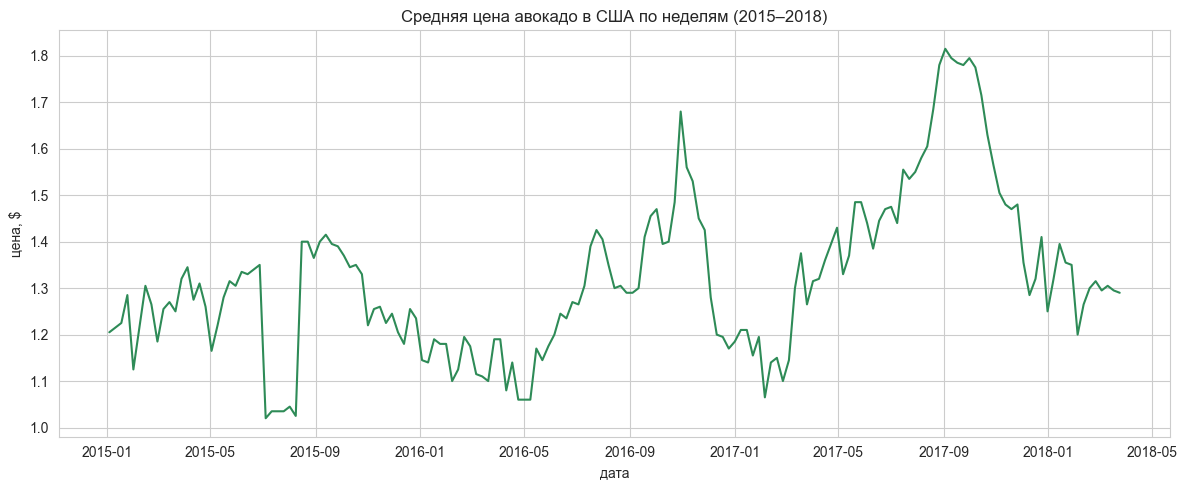

In [50]:
avg_price_by_date = us_df.groupby('Date')['AveragePrice'].mean()

plt.figure(figsize=(12, 5))
plt.plot(avg_price_by_date.index, avg_price_by_date.values, color='seagreen')
plt.title('Средняя цена авокадо в США по неделям (2015–2018)')
plt.xlabel('дата')
plt.ylabel('цена, $')
plt.tight_layout()
plt.show()


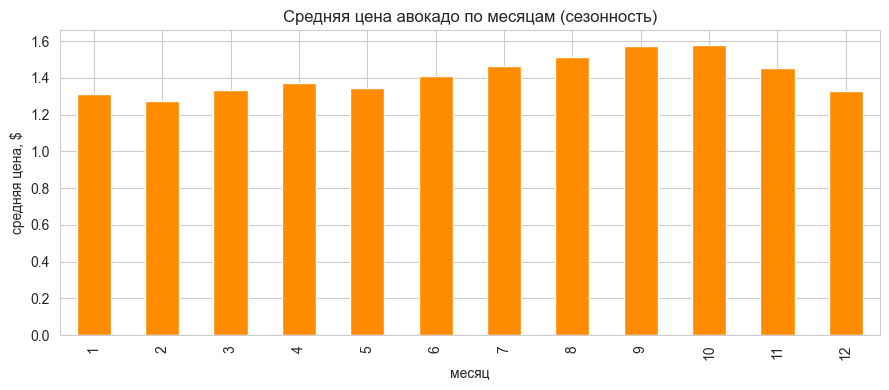

Самый дорогой месяц: 10 (в среднем 1.58$)
Самый дешёвый месяц: 2 (в среднем 1.27$)


In [51]:
df['month'] = df['Date'].dt.month
seasonal_price = df.groupby('month')['AveragePrice'].mean()

plt.figure(figsize=(9, 4))
seasonal_price.plot(kind='bar', color='darkorange')
plt.title('Средняя цена авокадо по месяцам (сезонность)')
plt.xlabel('месяц')
plt.ylabel('средняя цена, $')
plt.tight_layout()
plt.show()

peak_month = seasonal_price.idxmax()
low_month = seasonal_price.idxmin()
print(f"Самый дорогой месяц: {peak_month} (в среднем {seasonal_price[peak_month]:.2f}$)")
print(f"Самый дешёвый месяц: {low_month} (в среднем {seasonal_price[low_month]:.2f}$)")


**Вывод по сезонности:** цена заметно растёт с весны и достигает пика к осени (сентябрь–октябрь),
после чего падает к зиме. Разница между самым дешёвым и самым дорогим месяцем — около 0.3$ за штуку,
это ~23% от средней цены. Это похоже на классический эффект сезонного спроса/предложения в сельском хозяйстве.

## 5. Organic vs Conventional

Средняя цена по типу:
type
conventional    1.158040
organic         1.653999
Name: AveragePrice, dtype: float64

Organic в среднем дороже conventional на 42.8%


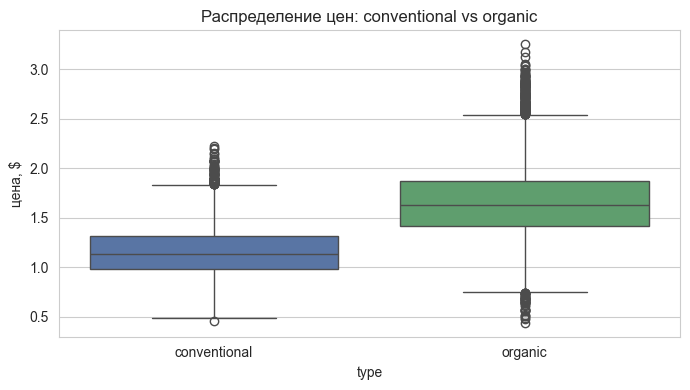

In [52]:
price_by_type = df.groupby('type')['AveragePrice'].mean()
print("Средняя цена по типу:")
print(price_by_type)

premium_pct = (price_by_type['organic'] / price_by_type['conventional'] - 1) * 100
print(f"\nOrganic в среднем дороже conventional на {premium_pct:.1f}%")

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='type', y='AveragePrice', hue='type', palette=['#4c72b0', '#55a868'], legend=False)
plt.title('Распределение цен: conventional vs organic')
plt.ylabel('цена, $')
plt.tight_layout()
plt.show()


type  organic_share
year               
2015           2.03
2016           2.71
2017           3.41
2018           3.51


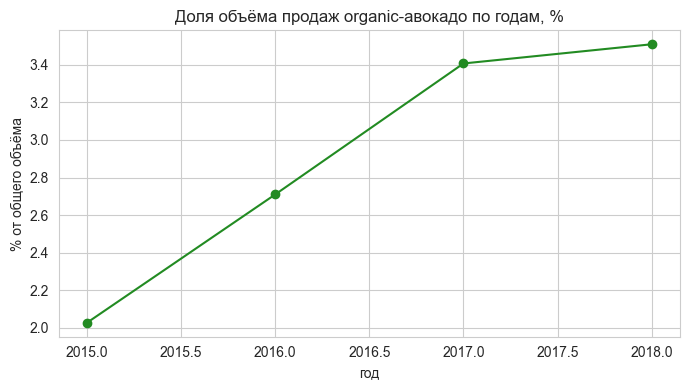

In [53]:
# Доля объёма продаж (Total Volume), приходящаяся на organic, по годам
org_share = (
    df.groupby(['year', 'type'])['Total Volume'].sum()
    .unstack()
    .assign(organic_share=lambda x: x['organic'] / (x['organic'] + x['conventional']) * 100)
)
print(org_share[['organic_share']].round(2))

plt.figure(figsize=(7, 4))
org_share['organic_share'].plot(kind='line', marker='o', color='forestgreen')
plt.title('Доля объёма продаж organic-авокадо по годам, %')
plt.ylabel('% от общего объёма')
plt.xlabel('год')
plt.tight_layout()
plt.show()


**Вывод organic vs conventional:** органический авокадо стабильно дороже обычного (в среднем на ~43%),
и это устойчивая премия, а не разовый всплеск. При этом доля organic в объёме продаж хоть и растёт год к году
(с ~2.0% в 2015 до ~3.5% в 2018), остаётся нишевой — это по-прежнему менее 4% рынка авокадо в США за
рассматриваемый период. Вывод для бизнеса: органика — премиальный, но пока очень узкий сегмент.

## 6. Цены по регионам

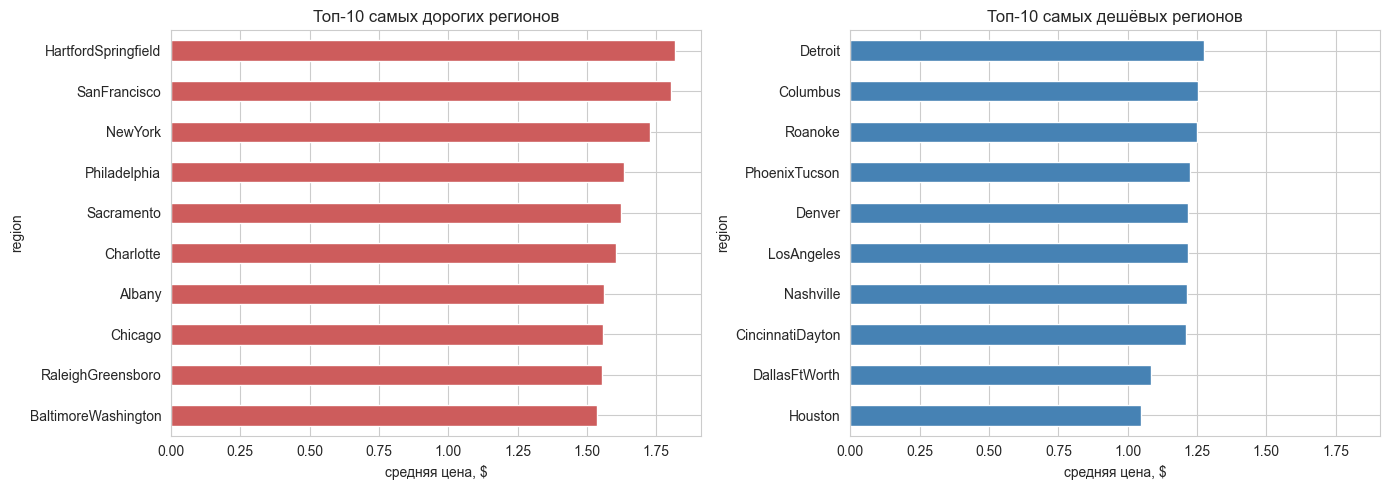

Самый дорогой регион: HartfordSpringfield (1.82$)
Самый дешёвый регион: Houston (1.05$)
Разброс между самым дорогим и дешёвым регионом: 0.77$


In [54]:
region_price = city_df.groupby('region')['AveragePrice'].mean().sort_values(ascending=False)

top10 = region_price.head(10)
bottom10 = region_price.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
top10.sort_values().plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Топ-10 самых дорогих регионов')
axes[0].set_xlabel('средняя цена, $')

bottom10.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Топ-10 самых дешёвых регионов')
axes[1].set_xlabel('средняя цена, $')

plt.tight_layout()
plt.show()

print(f"Самый дорогой регион: {region_price.index[0]} ({region_price.iloc[0]:.2f}$)")
print(f"Самый дешёвый регион: {region_price.index[-1]} ({region_price.iloc[-1]:.2f}$)")
print(f"Разброс между самым дорогим и дешёвым регионом: {region_price.iloc[0] - region_price.iloc[-1]:.2f}$")


**Вывод по регионам:** самые высокие цены — в HartfordSpringfield, Сан-Франциско и Нью-Йорке
(дорогие северо-восточные и калифорнийские рынки), самые низкие — в Хьюстоне и Далласе (Техас, ближе
к производству/логистике). Разброс между крайними регионами — больше 0.7$, то есть почти двукратная
разница в цене на один и тот же товар в зависимости от региона.

## 7. Связь цены и объёма продаж

Корреляция цены и log(объёма продаж): -0.58


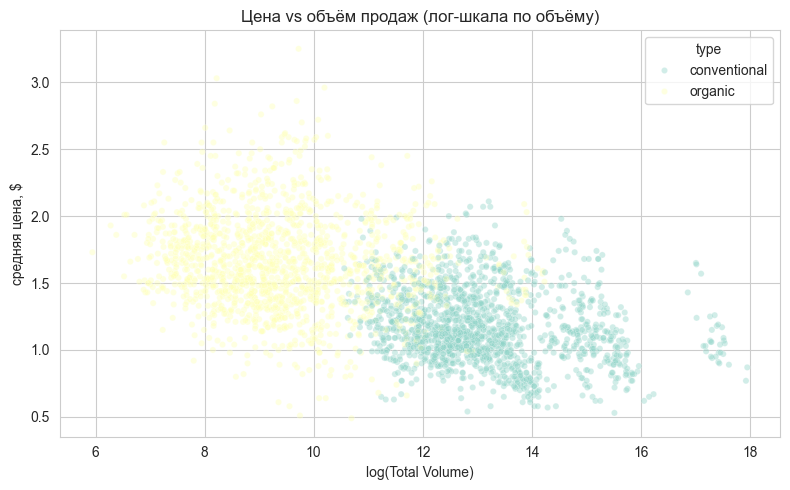

In [55]:
df['log_volume'] = np.log1p(df['Total Volume'])
corr = df['AveragePrice'].corr(df['log_volume'])
print(f"Корреляция цены и log(объёма продаж): {corr:.2f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(3000, random_state=42), x='log_volume', y='AveragePrice',
                 hue='type', alpha=0.4, s=20)
plt.title('Цена vs объём продаж (лог-шкала по объёму)')
plt.xlabel('log(Total Volume)')
plt.ylabel('средняя цена, $')
plt.tight_layout()
plt.show()


**Вывод по цене и объёму:** корреляция около -0.58 — умеренно сильная отрицательная связь: там,
где продают больше авокадо, цена в среднем ниже. Это ожидаемо с точки зрения экономики (эффект масштаба
и эластичность спроса), но напрямую причинность отсюда не доказать — корреляция могла быть создана и
типом продукта (organic одновременно и дороже, и продаётся в меньших объёмах).

## 8. Оконные функции: аналог SQL (RANK, LAG) на pandas

Ниже — то же самое, что можно сделать оконными функциями в SQL (`RANK() OVER (PARTITION BY ...)`,
`LAG() OVER (ORDER BY ...)`), но средствами pandas. Это показывает, что логика window functions
одинаковая что в SQL, что в pandas — просто другой синтаксис.

In [56]:
# Аналог RANK() OVER (PARTITION BY year ORDER BY AveragePrice DESC) —
# ранжируем регионы по средней цене внутри каждого года
yearly_region_price = (
    city_df.groupby(['year', 'region'])['AveragePrice'].mean()
    .reset_index()
)
yearly_region_price['price_rank'] = (
    yearly_region_price.groupby('year')['AveragePrice']
    .rank(method='dense', ascending=False)
    .astype(int)
)

# топ-3 самых дорогих региона по каждому году, как SELECT ... WHERE price_rank <= 3
top3_per_year = yearly_region_price[yearly_region_price['price_rank'] <= 3].sort_values(['year', 'price_rank'])
top3_per_year


,year,region,AveragePrice,price_rank
16,2015,HartfordSpringfield,1.747788,1
26,2015,NewYork,1.644519,2
38,2015,SanFrancisco,1.621058,3
83,2016,SanFrancisco,1.881250,1
61,2016,HartfordSpringfield,1.851058,2
71,2016,NewYork,1.762019,3
128,2017,SanFrancisco,1.965943,1
106,2017,HartfordSpringfield,1.888302,2
116,2017,NewYork,1.809906,3
151,2018,HartfordSpringfield,1.677500,1


In [57]:
# Аналог LAG() OVER (PARTITION BY region ORDER BY Date) —
# смотрим изменение цены к предыдущей неделе в этом же регионе
city_df_sorted = city_df.sort_values(['region', 'type', 'Date']).copy()
city_df_sorted['prev_week_price'] = city_df_sorted.groupby(['region', 'type'])['AveragePrice'].shift(1)
city_df_sorted['price_change'] = city_df_sorted['AveragePrice'] - city_df_sorted['prev_week_price']

# недели с самым резким скачком цены вверх
city_df_sorted.nlargest(5, 'price_change')[['Date', 'region', 'type', 'prev_week_price', 'AveragePrice', 'price_change']]


,Date,region,type,prev_week_price,AveragePrice,price_change
15259,2017-03-19,CincinnatiDayton,organic,0.64,1.68,1.04
11993,2016-10-30,Atlanta,organic,1.25,2.25,1.00
17013,2017-02-12,SanFrancisco,organic,1.61,2.59,0.98
14149,2016-05-15,SanFrancisco,organic,1.32,2.27,0.95
15254,2017-04-23,CincinnatiDayton,organic,0.98,1.92,0.94


## 9. Итоговые выводы

1. **Сезонность есть и она заметная.** Цена на авокадо растёт с весны и достигает пика в сентябре–октябре,
   а потом падает к зиме. Разница между самым дешёвым (февраль) и самым дорогим (октябрь) месяцем около 23% от
   средней цены. Для закупщика это значит: планировать закупки на весну/зиму, если задача — сэкономить.
2. **Organic — устойчиво премиальный, но узкий сегмент.** Органический авокадо в среднем на ~43% дороже
   обычного, и премия не сокращается со временем. При этом доля organic в объёме продаж выросла с ~2% (2015)
   до ~3.5% (2018) — тренд к росту есть, но сегмент остаётся нишевым.
3. **Регион сильно влияет на цену.** Разброс между самым дорогим (HartfordSpringfield) и самым дешёвым
   (Хьюстон) регионом — больше 0.7$ за штуку, почти двукратная разница. Северо-восток и Калифорния дороже,
   южные штаты (Техас) — дешевле.
4. **Цена и объём продаж обратно связаны** (корреляция ≈ -0.58): в регионах/периодах с большим объёмом продаж
   цена в среднем ниже. Связь умеренная, причинность отдельно не проверялась.

**Ограничения анализа:** данные охватывают только 2015 – начало 2018 года и только США; в датасете нет
показателей затрат/себестоимости, поэтому "дороже" и "дешевле" здесь — исключительно про розничную цену,
а не про маржинальность.
